In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Калибровка камеры по одному кадру.

ЗАДАНИЕ: по заданным парам точек $x_i$ на изображении и $X_i$ в пространстве
необходимо найти оценку матрицы перспективной камеры $\mathbf{M}$,
т.е. решить PnP задачу (см лекцию 1).

Алгоритм должен включать следующие этапы:
1. Инициализация матрицы камеры $\mathbf{M}$ методом DLT, БЕЗ Ransac.
2. Уточнение матрицы камеры $\mathbf{M}$ методом градиентной оптимизации
ошибки репроекции вида:
$$\mathcal{L}(x_i, X_i) = \sum\| \mathbf{M}X_i - x_i \|^2$$
3. Факторизация матрицы $\mathbf{M}$ на внешние и внутренние параметры.

In [2]:
%%bash
if [ ! -d assets/ ]; then
    curl -sO 'https://code.mipt.ru/courses-public/cv/storage/-/raw/tasks/camera-calibration/assets.zip'
    unzip -qo assets.zip
fi

In [3]:
image_path = 'assets/image.jpg'
corners_path = 'assets/corners.txt'
coords_path = 'assets/coords.txt'

(1280, 960, 3)

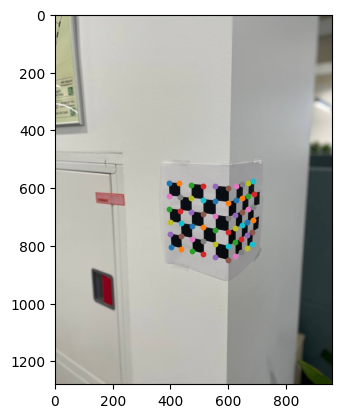

In [4]:
x3d = np.loadtxt(coords_path)
x2d = np.loadtxt(corners_path)

img = cv2.imread(image_path)
h, w, _ = img.shape
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
for x in x2d:
    plt.scatter(*x, s=10)

img.shape

Ожидаемый результат:<br/><img src="https://code.mipt.ru/courses-public/cv/storage/-/raw/tasks/camera-calibration/image1.png" style="display:inline-block"/>

In [5]:
def to_homo(x):
    return np.concatenate([x, np.ones(x.shape[0])[..., None]], axis=1)

def to_cartesian(x):
    return (x / x[..., -1:])[..., :-1]

def geometric_distance(x, y):
    return np.sum((x-y)**2)

## Шаг 1. DLT инициализация матрицы камеры
Линейная оценка матрицы камеры может быть получена из решения линейного уравнения вида (см лекция 1):
$$\Large A \cdot \vec{m}^T = 0$$

In [6]:
def build_system(x3d, x2d):
    # input: x3d - world points
    #        x2d - pixel coords
    # ouptut: A - [2n, 12] matrix
    N = x3d.shape[0]
    A = np.zeros((2*N, 12))

    for i in range(N):
        X, Y, Z, _ = x3d[i]
        x, y, _ = x2d[i]

        # First equation for x (even)
        A[2*i, 0] = X
        A[2*i, 1] = Y
        A[2*i, 2] = Z
        A[2*i, 3] = 1

        # Coefficient for m31, m32, m33, m34 (-)
        A[2*i, 8] = -X * x
        A[2*i, 9] = -Y * x
        A[2*i, 10] = -Z * x
        A[2*i, 11] = -x

        # Second equation for y (odd)
        A[2*i+1, 4] = X
        A[2*i+1, 5] = Y
        A[2*i+1, 6] = Z
        A[2*i+1, 7] = 1

        # Coefficient for m31, m32, m33, m34 (-)
        A[2*i+1, 8] = -X * y
        A[2*i+1, 9] = -Y * y
        A[2*i+1, 10] = -Z * y
        A[2*i+1, 11] = -y

        # Others with 0

    return A

def solve_system(A):
    # input: A - matrix
    # output: solution for Am = 0

    # The matrix A^T * A
    ATA = A.T @ A

    # Finding eigenvalues ​​and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(ATA)

    # Finding the index of the smallest eigenvalue
    min_eigenvalue_index = np.argmin(eigenvalues)

    # The corresponding eigenvector is the solution
    m = eigenvectors[:, min_eigenvalue_index].real

    # Convert to real numbers (without the complex part)
    m = m.real

    # Normalize
    m = m / m[-1]

    print(f"m shape: {m.shape}")
    print(f"m: {m}")

    return m

In [7]:
A = build_system(to_homo(x3d), to_homo(x2d))
M = solve_system(A).reshape(3,4)

m shape: (12,)
m: [ 4.84025766e+01 -2.80249565e+01 -5.97273525e+00  5.99223978e+02
  1.78294948e+01  1.34173223e+01 -5.66494871e+01  8.49689975e+02
  4.03170191e-02  2.85287216e-02 -1.06821360e-02  1.00000000e+00]


In [8]:
coarse = geometric_distance(x2d, to_cartesian((M@to_homo(x3d).T).T))
assert coarse < 50

### Шаг 2. Уточнение матрицы градиентным методом

Для уточнения матрицы $\mathbf{M}$ используем градиентный метод оптимизации: Levenberg-Marquardt algorithm.
Рекомендуется использовать его имплементацию из пакета scipy.


In [9]:
from scipy.optimize import least_squares

def refine(DLT_M):
    # input: DLT_M - coarse estimate
    # (optional) x2d, x3d
    # output: refined solution for M

    # Transform the initial matrix into a flat vector
    m0 = DLT_M.ravel()

    # The function we will optimize
    def fun(m_params):
        # Reconstructing a 3x4 matrix from a vector
        M = m_params.reshape(3, 4)

        # Projecting 3D points
        x3d_homo = to_homo(x3d)
        x_proj_homo = (M @ x3d_homo.T).T
        x_proj = to_cartesian(x_proj_homo)

        # Calculate the difference (dx, dy for each point)
        diff = x_proj - x2d

        # 'least_squares' need a flat array
        return diff.ravel()

    # Launching optimization
    result = least_squares(fun, m0, method='lm')

    # Return the refined matrix
    return result.x.reshape(3, 4)

In [10]:
M = refine(M)

In [11]:
fine = geometric_distance(x2d, to_cartesian((M@to_homo(x3d).T).T))
assert fine < coarse

### Шаг 3. Факторизация матрицы камеры
На этом этапе необходимо получить внешиние и внутренние параметры камеры вида:
$$\mathbf{M} = \mathbf{K} \big[\mathbf{R} | \mathbf{t}\big]$$

$\mathbf{K}$ - верхнетреугольная матрица с положительными числами

$\mathbf{R}$ - ортогональная матрица с положительным детерминантом

$t$ - вектор из трех чисел

In [12]:
def factorize(M):
    # input: M
    # output: K, R, t

    K, R, t, _, _, _, _ = cv2.decomposeProjectionMatrix(M)
    K = K / K[2, 2]
    t = t[:3].flatten() / t[3]
    return K, R, t

In [13]:
K, R, t = factorize(M)
print(f"{K = }")
print(f"{R = }")
print(f"{t = }")

K = array([[1.00435767e+03, 4.58526086e+00, 4.77427865e+02],
       [0.00000000e+00, 1.00052084e+03, 6.65827567e+02],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])
R = array([[ 0.57504166, -0.81802941, -0.01244892],
       [-0.17785886, -0.11014617, -0.9778722 ],
       [ 0.79855702,  0.56453141, -0.20883241]])
t = array([-16.48675135,  -8.80151788,   7.70135017])


In [14]:
assert np.isclose(K[2,2], 1)
assert np.isclose(np.linalg.det(R), 1)
assert np.abs(K[0,2] - 960 / 2) < 30
assert np.abs(K[1,2] - 1280 / 2) < 30
assert (K[0, 0] > 1000) & (K[1, 1] > 1000)

In [15]:
def make_grid(M):
    x3d = [[0, i, k] for i in range(10) for k in range(-5, 10)] + [[i, 0, k] for i in range(10) for k in range(-5, 10)]
    x3d = np.array(x3d)

    x2d = to_cartesian((M@to_homo(x3d).T).T)

    plt.subplots(figsize=(10, 10))
    plt.imshow(img)
    plt.scatter(x2d[..., 0], x2d[..., 1], s=20, color='green', marker='x')

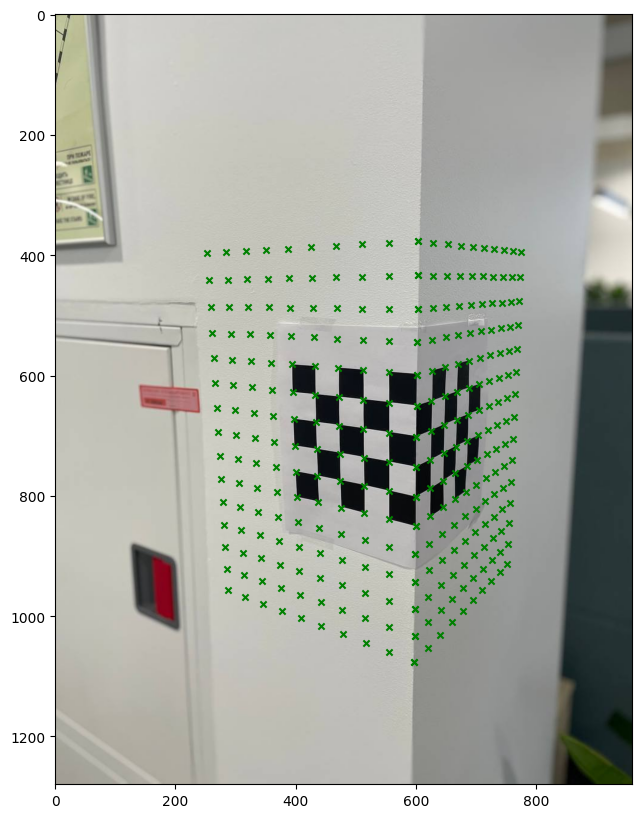

In [16]:
make_grid(M)

Ожидаемый результат:<br/><img src="https://code.mipt.ru/courses-public/cv/storage/-/raw/tasks/camera-calibration/image2.png" style="display:inline-block"/>